In [1]:
# ============================================================================
# CELL 1: Imports and Setup
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import transforms, models
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import copy
import os

# Import custom dataset (must be in separate file for Windows multiprocessing)
from JSRTDataset import JSRTNoduleDataset

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [2]:
# ============================================================================
# CELL 2: Hyperparameters
# ============================================================================
batch_size = 16
num_epochs = 20
learning_rate = 0.0001
num_classes = 3
n_folds = 5
target_train_samples_per_class = 500  # Augment training folds to this size


In [3]:
# ============================================================================
# CELL 3: Data Transforms
# ============================================================================
# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# ============================================================================
# CELL 4: Load Datasets
# ============================================================================
# Load trainval dataset (ORIGINAL images only for cross-validation)
trainval_dataset_original = JSRTNoduleDataset(
    csv_path='./dataset_nodule_augmented/trainval_metadata.csv',
    root_dir='./dataset_nodule_augmented/',
    transform=val_test_transform  # Start with no augmentation
)

# Load test dataset
test_dataset = JSRTNoduleDataset(
    csv_path='./dataset_nodule_augmented/test_metadata.csv',
    root_dir='./dataset_nodule_augmented/',
    transform=val_test_transform
)

print(f'TrainVal samples (ORIGINAL): {len(trainval_dataset_original)}')
print(f'Test samples: {len(test_dataset)}')

TrainVal samples (ORIGINAL): 199
Test samples: 48


In [5]:
# ============================================================================
# CELL 5: Create Augmented Dataset Class for Training
# ============================================================================
import random
from scipy.ndimage import rotate as scipy_rotate, shift as scipy_shift
from PIL import Image

class AugmentedSubset(torch.utils.data.Dataset):
    """
    Wraps a subset and applies on-the-fly augmentation to reach target size.
    Each epoch generates different augmentations.
    """
    def __init__(self, dataset, indices, target_size, transform, augment=True):
        self.base_dataset = dataset
        self.indices = list(indices)
        self.target_size = target_size
        self.transform = transform
        self.augment = augment
        
        # If we need more samples, calculate how many augmented versions per original
        self.original_size = len(self.indices)
        if augment and target_size > self.original_size:
            self.aug_per_original = (target_size // self.original_size) + 1
        else:
            self.aug_per_original = 1
    
    def __len__(self):
        if self.augment:
            return min(self.target_size, self.original_size * self.aug_per_original)
        return self.original_size
    
    def augment_image(self, img_array):
        """Apply random augmentation to numpy array"""
        aug_type = random.choice(['h_translation', 'v_translation', 'rotation', 
                                 'brightness', 'h_flip', 'combined'])
        
        # Handle RGB images (H, W, 3)
        is_rgb = len(img_array.shape) == 3
        
        if aug_type == 'h_translation':
            shift_pct = np.random.uniform(-0.02, 0.02)
            shift_pixels = shift_pct * img_array.shape[1]
            if is_rgb:
                return scipy_shift(img_array, shift=[0, shift_pixels, 0], mode='nearest')
            else:
                return scipy_shift(img_array, shift=[0, shift_pixels], mode='nearest')
        
        elif aug_type == 'v_translation':
            shift_pct = np.random.uniform(-0.02, 0.02)
            shift_pixels = shift_pct * img_array.shape[0]
            if is_rgb:
                return scipy_shift(img_array, shift=[shift_pixels, 0, 0], mode='nearest')
            else:
                return scipy_shift(img_array, shift=[shift_pixels, 0], mode='nearest')
        
        elif aug_type == 'rotation':
            angle = np.random.uniform(-3, 3)
            if is_rgb:
                return scipy_rotate(img_array, angle, axes=(0, 1), reshape=False, mode='nearest')
            else:
                return scipy_rotate(img_array, angle, reshape=False, mode='nearest')
        
        elif aug_type == 'brightness':
            factor = np.random.uniform(0.95, 1.05)
            return np.clip(img_array * factor, 0, 255)
        
        elif aug_type == 'h_flip':
            return np.fliplr(img_array)
        
        elif aug_type == 'combined':
            h_shift_pct = np.random.uniform(-0.01, 0.01)
            h_shift_pixels = h_shift_pct * img_array.shape[1]
            if is_rgb:
                shifted = scipy_shift(img_array, shift=[0, h_shift_pixels, 0], mode='nearest')
            else:
                shifted = scipy_shift(img_array, shift=[0, h_shift_pixels], mode='nearest')
            angle = np.random.uniform(-2, 2)
            if is_rgb:
                return scipy_rotate(shifted, angle, axes=(0, 1), reshape=False, mode='nearest')
            else:
                return scipy_rotate(shifted, angle, reshape=False, mode='nearest')
        
        return img_array
    
    def __getitem__(self, idx):
        # Map to original index (with wrapping for augmentation)
        orig_idx = self.indices[idx % self.original_size]
        
        # Load image directly from file path (bypass the dataset's transform)
        img_metadata = self.base_dataset.metadata.iloc[orig_idx]
        img_path = os.path.join(self.base_dataset.root_dir, img_metadata['filepath'])
        img = Image.open(img_path).convert('RGB')
        label = self.base_dataset.class_to_idx[img_metadata['class']]
        
        # If augmenting and this is an augmented copy, apply augmentation
        if self.augment and idx >= self.original_size:
            # Convert PIL to numpy for augmentation
            img_array = np.array(img)
            img_array = self.augment_image(img_array)
            # Convert back to PIL
            img = Image.fromarray(img_array.astype(np.uint8))
        
        # Apply transforms (resize, normalize, etc.)
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [6]:
# ============================================================================
# CELL 6: Prepare Stratified K-Fold
# ============================================================================
# Get labels for stratification
trainval_labels = [trainval_dataset_original[i][1] for i in range(len(trainval_dataset_original))]

# Create stratified k-fold
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f'\n{n_folds}-Fold Stratified Cross-Validation Setup Complete')
print(f'Each fold will have approximately {len(trainval_dataset_original)//n_folds} validation samples')
print(f'Training folds will be augmented to {target_train_samples_per_class} samples per class')


5-Fold Stratified Cross-Validation Setup Complete
Each fold will have approximately 39 validation samples
Training folds will be augmented to 500 samples per class


In [7]:
# ============================================================================
# CELL 7: Define ResNet50-FPN Model
# ============================================================================
class ResNet50FPN(nn.Module):
    def __init__(self, num_classes=3, pretrained_path=None, freeze_backbone=True):
        super(ResNet50FPN, self).__init__()
        
        # Load ResNet50 backbone
        resnet = models.resnet50(pretrained=False)
        
        # Extract feature layers
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1  # 256 channels
        self.layer2 = resnet.layer2  # 512 channels
        self.layer3 = resnet.layer3  # 1024 channels
        self.layer4 = resnet.layer4  # 2048 channels
        
        # FPN lateral connections (reduce channels to 256)
        self.lateral4 = nn.Conv2d(2048, 256, kernel_size=1)
        self.lateral3 = nn.Conv2d(1024, 256, kernel_size=1)
        self.lateral2 = nn.Conv2d(512, 256, kernel_size=1)
        self.lateral1 = nn.Conv2d(256, 256, kernel_size=1)
        
        # FPN output convolutions (smooth the upsampled features)
        self.output4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.output3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.output2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.output1 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        
        # Global Average Pooling and classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256 * 4, num_classes)  # 4 FPN levels concatenated
        
        # Load pretrained binary weights if provided
        if pretrained_path:
            self._load_pretrained_weights(pretrained_path)
        
        # Freeze backbone if requested
        if freeze_backbone:
            self._freeze_backbone()
            print('Backbone frozen - only FPN and FC layers are trainable')
    
    def _load_pretrained_weights(self, path):
        # Load binary model weights into backbone
        binary_model = models.resnet50(pretrained=False)
        binary_model.fc = nn.Linear(binary_model.fc.in_features, 2)
        
        checkpoint = torch.load(path, map_location='cpu')
        
        # Handle different checkpoint formats
        if 'model_state_dict' in checkpoint:
            # Checkpoint contains metadata (epoch, optimizer, etc.)
            state_dict = checkpoint['model_state_dict']
        elif isinstance(checkpoint, dict) and 'conv1.weight' in checkpoint:
            # Checkpoint is already a state dict
            state_dict = checkpoint
        else:
            raise ValueError("Unknown checkpoint format. Expected 'model_state_dict' key or direct state_dict.")
        
        binary_model.load_state_dict(state_dict)
        
        # Transfer backbone weights
        self.conv1.load_state_dict(binary_model.conv1.state_dict())
        self.bn1.load_state_dict(binary_model.bn1.state_dict())
        self.layer1.load_state_dict(binary_model.layer1.state_dict())
        self.layer2.load_state_dict(binary_model.layer2.state_dict())
        self.layer3.load_state_dict(binary_model.layer3.state_dict())
        self.layer4.load_state_dict(binary_model.layer4.state_dict())
        
        print('Loaded binary model weights into ResNet50-FPN backbone')
    
    def _freeze_backbone(self):
        # Freeze all backbone layers
        for param in self.conv1.parameters():
            param.requires_grad = False
        for param in self.bn1.parameters():
            param.requires_grad = False
        for param in self.layer1.parameters():
            param.requires_grad = False
        for param in self.layer2.parameters():
            param.requires_grad = False
        for param in self.layer3.parameters():
            param.requires_grad = False
        for param in self.layer4.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        # Bottom-up pathway (ResNet50)
        c1 = self.relu(self.bn1(self.conv1(x)))
        c1 = self.maxpool(c1)
        c1 = self.layer1(c1)  # 1/4 resolution
        c2 = self.layer2(c1)   # 1/8 resolution
        c3 = self.layer3(c2)   # 1/16 resolution
        c4 = self.layer4(c3)   # 1/32 resolution
        
        # Top-down pathway and lateral connections
        p4 = self.lateral4(c4)
        p3 = self.lateral3(c3) + nn.functional.interpolate(p4, size=c3.shape[2:], mode='nearest')
        p2 = self.lateral2(c2) + nn.functional.interpolate(p3, size=c2.shape[2:], mode='nearest')
        p1 = self.lateral1(c1) + nn.functional.interpolate(p2, size=c1.shape[2:], mode='nearest')
        
        # Apply output convolutions
        p4 = self.output4(p4)
        p3 = self.output3(p3)
        p2 = self.output2(p2)
        p1 = self.output1(p1)
        
        # Global pooling on each pyramid level
        f4 = self.global_pool(p4).flatten(1)
        f3 = self.global_pool(p3).flatten(1)
        f2 = self.global_pool(p2).flatten(1)
        f1 = self.global_pool(p1).flatten(1)
        
        # Concatenate multi-scale features
        features = torch.cat([f1, f2, f3, f4], dim=1)
        
        # Classification
        out = self.fc(features)
        return out

In [8]:
# ============================================================================
# CELL 8: Define Training Function
# ============================================================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [9]:
# ============================================================================
# CELL 9: Define Validation Function
# ============================================================================
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    
    # Calculate metrics
    precision, recall, _, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    
    # Calculate AUC (one-vs-rest)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except:
        auc = 0.0
    
    return epoch_loss, epoch_acc, precision, recall, auc, all_labels, all_preds



In [10]:
# ============================================================================
# CELL 10: Cross-Validation Training Loop
# ============================================================================
print('\n' + '='*70)
print('STARTING 5-FOLD CROSS-VALIDATION')
print('='*70)

# Store results for each fold
fold_results = []
all_fold_histories = []

criterion = nn.CrossEntropyLoss()

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(trainval_dataset_original)), trainval_labels)):
    print(f'\n{"="*70}')
    print(f'FOLD {fold + 1}/{n_folds}')
    print(f'{"="*70}')
    
    # Count samples per class in training fold
    train_labels = [trainval_labels[i] for i in train_idx]
    samples_per_class = [train_labels.count(i) for i in range(num_classes)]
    target_size = target_train_samples_per_class * num_classes
    
    print(f'Original train samples: {len(train_idx)} (per class: {samples_per_class})')
    print(f'Target train samples after augmentation: {target_size}')
    print(f'Validation samples: {len(val_idx)}')
    
    # Create augmented training set and validation set
    train_dataset_aug = AugmentedSubset(
        trainval_dataset_original, train_idx, target_size, train_transform, augment=True
    )
    val_dataset_orig = AugmentedSubset(
        trainval_dataset_original, val_idx, len(val_idx), val_test_transform, augment=False
    )
    
    print(f'Actual augmented train samples: {len(train_dataset_aug)}')
    
    # Create data loaders
    train_loader = DataLoader(train_dataset_aug, batch_size=batch_size, 
                             shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset_orig, batch_size=batch_size,
                           shuffle=False, num_workers=4)
    
    # Create fresh model for this fold
    model = ResNet50FPN(num_classes=num_classes, 
                       pretrained_path='./resnet50_binary.pth',
                       freeze_backbone=True)
    model = model.to(device)
    
    # Count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Trainable parameters: {trainable_params:,} / {total_params:,} '
          f'({100*trainable_params/total_params:.1f}%)')
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                          lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                     patience=3, factor=0.5)
    
    # Training history for this fold
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_auc': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        
        # Train (with augmentation)
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate (no augmentation)
        val_loss, val_acc, val_precision, val_recall, val_auc, _, _ = validate(
            model, val_loader, criterion, device
        )
        
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_auc'].append(val_auc)
        
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, '
              f'Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, AUC: {val_auc:.4f}')
        
        # Save best model for this fold
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            print('✓ Best model updated')
    
    # Load best model and evaluate on validation set
    model.load_state_dict(best_model_state)
    val_loss, val_acc, val_precision, val_recall, val_auc, val_labels, val_preds = validate(
        model, val_loader, criterion, device
    )
    
    fold_results.append({
        'fold': fold + 1,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_auc': val_auc
    })
    
    all_fold_histories.append(history)
    
    print(f'\nFold {fold + 1} Best Results:')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, AUC: {val_auc:.4f}')
    
    # Save best model for this fold
    torch.save(best_model_state, f'./resnet50_fpn_fold{fold+1}.pth')




STARTING 5-FOLD CROSS-VALIDATION

FOLD 1/5
Original train samples: 159 (per class: [35, 64, 60])
Target train samples after augmentation: 1500
Validation samples: 40
Actual augmented train samples: 1500


c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded binary model weights into ResNet50-FPN backbone
Backbone frozen - only FPN and FC layers are trainable
Trainable parameters: 3,347,459 / 26,855,491 (12.5%)

Epoch 1/20


RuntimeError: DataLoader worker (pid(s) 19824, 16664, 20816, 20560) exited unexpectedly

In [ ]:
# ============================================================================
# CELL 11: Cross-Validation Results Summary
# ============================================================================
print('\n' + '='*70)
print('CROSS-VALIDATION RESULTS SUMMARY')
print('='*70)

results_df = pd.DataFrame(fold_results)
print('\nPer-Fold Results:')
print(results_df.to_string(index=False))

print('\nMean ± Std across folds:')
for metric in ['val_acc', 'val_precision', 'val_recall', 'val_auc', 'val_loss']:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    print(f'{metric:15s}: {mean:.4f} ± {std:.4f}')


TRAINING FINAL MODEL ON ALL TRAIN+VAL DATA


c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded binary model weights into ResNet50-FPN backbone
Backbone frozen - only FPN and FC layers are trainable
Training final model for 20 epochs...

Epoch 1/20


Train Loss: 1.1118, Train Acc: 0.4190
Epoch 2/20


Train Loss: 0.9886, Train Acc: 0.5113
Epoch 3/20


...

Train Loss: 0.5267, Train Acc: 0.7853
Epoch 17/20


Train Loss: 0.5673, Train Acc: 0.7640
Epoch 18/20


Train Loss: 0.5066, Train Acc: 0.7980
Epoch 19/20


Train Loss: 0.4974, Train Acc: 0.7927
Epoch 20/20


Train Loss: 0.5083, Train Acc: 0.7920

✓ Final model saved as resnet50_fpn_final.pth


In [ ]:
# ============================================================================
# CELL 12: Train Final Model on All TrainVal Data
# ============================================================================
print('\n' + '='*70)
print('TRAINING FINAL MODEL ON ALL TRAINVAL DATA')
print('='*70)

# Create augmented dataset for all trainval data
all_indices = list(range(len(trainval_dataset_original)))
target_size = target_train_samples_per_class * num_classes
full_train_dataset = AugmentedSubset(
    trainval_dataset_original, all_indices, target_size, train_transform, augment=True
)
full_train_loader = DataLoader(full_train_dataset, batch_size=batch_size, 
                               shuffle=True, num_workers=4)

print(f'Training on {len(full_train_dataset)} samples (augmented from {len(trainval_dataset_original)} original)')

# Create final model
final_model = ResNet50FPN(num_classes=num_classes, 
                         pretrained_path='./resnet50_binary.pth',
                         freeze_backbone=True)
final_model = final_model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, final_model.parameters()), 
                      lr=learning_rate)

# Use average best epoch from CV
avg_best_epoch = int(np.mean([np.argmin(h['val_loss']) for h in all_fold_histories]))
final_epochs = min(avg_best_epoch + 5, num_epochs)  # Train a bit longer

print(f'Training final model for {final_epochs} epochs...\n')

for epoch in range(final_epochs):
    print(f'Epoch {epoch+1}/{final_epochs}')
    train_loss, train_acc = train_epoch(final_model, full_train_loader, criterion, optimizer, device)
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')

# Save final model
torch.save(final_model.state_dict(), './resnet50_fpn_final.pth')
print('\n✓ Final model saved as resnet50_fpn_final.pth')


EVALUATING ON HELD-OUT TEST SET



Test Results:
Test Loss: 1.6652
Test Accuracy: 0.4792
Test Precision: 0.4337
Test Recall: 0.4389
Test AUC: 0.6073


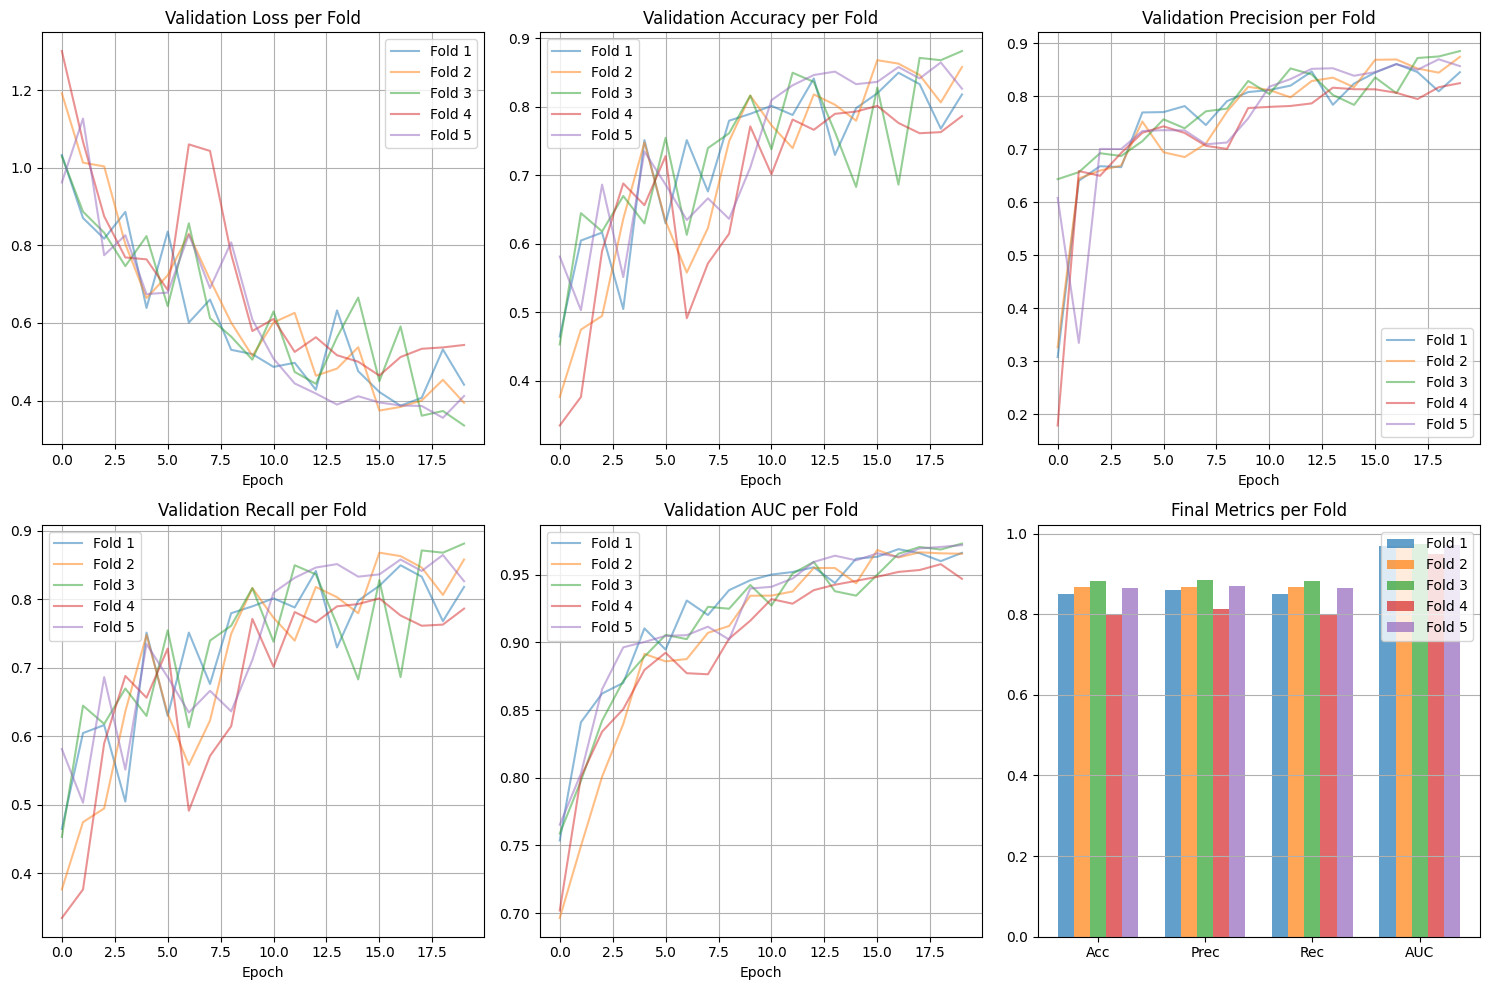

In [ ]:
# ============================================================================
# CELL 13: Test Set Evaluation
# ============================================================================
print('\n' + '='*70)
print('EVALUATING ON HELD-OUT TEST SET')
print('='*70)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

test_loss, test_acc, test_precision, test_recall, test_auc, test_labels, test_preds = validate(
    final_model, test_loader, criterion, device
)

print(f'\nTest Results:')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test AUC: {test_auc:.4f}')

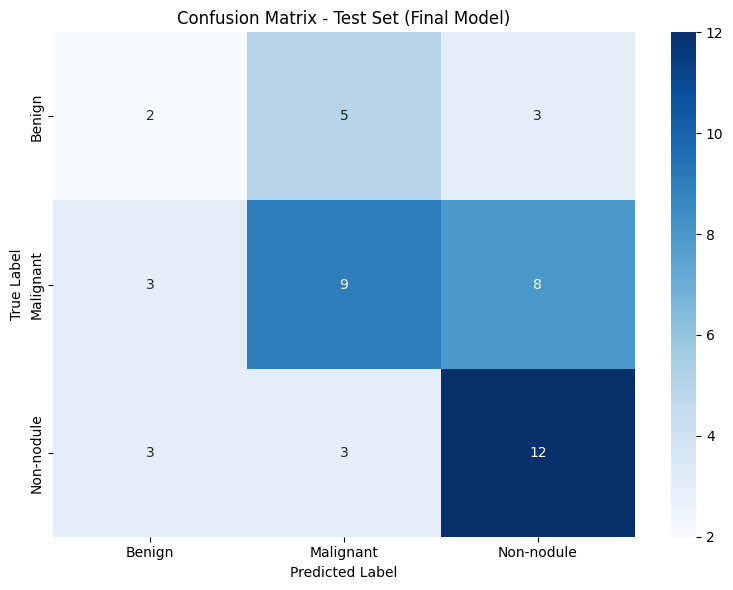

In [ ]:
# ============================================================================
# CELL 14: Plot CV Results
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot each fold's training history
for fold_idx, history in enumerate(all_fold_histories):
    axes[0, 0].plot(history['val_loss'], alpha=0.5, label=f'Fold {fold_idx+1}')
    axes[0, 1].plot(history['val_acc'], alpha=0.5, label=f'Fold {fold_idx+1}')
    axes[0, 2].plot(history['val_precision'], alpha=0.5, label=f'Fold {fold_idx+1}')
    axes[1, 0].plot(history['val_recall'], alpha=0.5, label=f'Fold {fold_idx+1}')
    axes[1, 1].plot(history['val_auc'], alpha=0.5, label=f'Fold {fold_idx+1}')

axes[0, 0].set_title('Validation Loss per Fold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].set_title('Validation Accuracy per Fold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].set_title('Validation Precision per Fold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True)

axes[1, 0].set_title('Validation Recall per Fold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].set_title('Validation AUC per Fold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Bar plot of final metrics per fold
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_auc']
x = np.arange(len(metrics))
for fold_idx, result in enumerate(fold_results):
    values = [result[m] for m in metrics]
    axes[1, 2].bar(x + fold_idx*0.15, values, width=0.15, 
                   label=f'Fold {fold_idx+1}', alpha=0.7)

axes[1, 2].set_xticks(x + 0.3)
axes[1, 2].set_xticklabels(['Acc', 'Prec', 'Rec', 'AUC'])
axes[1, 2].set_title('Final Metrics per Fold')
axes[1, 2].legend()
axes[1, 2].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 15: Confusion Matrix
# ============================================================================
cm = confusion_matrix(test_labels, test_preds)
class_names = ['Benign', 'Malignant', 'Non-nodule']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set (Final Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


Per-class metrics on test set:

Benign:
  Precision: 0.2500
  Recall: 0.2000
  F1-Score: 0.2222
  Support: 10

Malignant:
  Precision: 0.5294
  Recall: 0.4500
  F1-Score: 0.4865
  Support: 20

Non-nodule:
  Precision: 0.5217
  Recall: 0.6667
  F1-Score: 0.5854
  Support: 18

TRAINING COMPLETE!
Models saved:
  - resnet50_fpn_fold1.pth through resnet50_fpn_fold5.pth
  - resnet50_fpn_final.pth (trained on all train+val data)


In [ ]:
# ============================================================================
# CELL 16: Per-Class Metrics
# ============================================================================
print('\nPer-class metrics on test set:')
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0
)

for i, class_name in enumerate(class_names):
    print(f'\n{class_name}:')
    print(f'  Precision: {precision_per_class[i]:.4f}')
    print(f'  Recall: {recall_per_class[i]:.4f}')
    print(f'  F1-Score: {f1_per_class[i]:.4f}')
    print(f'  Support: {support[i]}')

print('\n' + '='*70)
print('TRAINING COMPLETE!')
print('='*70)
print(f'Models saved:')
print(f'  - resnet50_fpn_fold1.pth through resnet50_fpn_fold{n_folds}.pth')
print(f'  - resnet50_fpn_final.pth (trained on all train+val data)')